# 1.2 Autoencoders

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

We will be using

- **Pytorch**. Since pytorch can use GPUs or TPUs if available, it is usually better to force all data types to be `np.float32` or `int`.

- The **MNIST** digits classification dataset. Observe how **we normalize** the MNIST images.

## 1. Load data

In [2]:
mnist = pd.read_csv("local/data/mnist1.5k.csv.gz", compression="gzip", header=None).values
X=(mnist[:,1:785]/255.).astype(np.float32)
y=(mnist[:,0]).astype(int)
print("dimension de las imagenes y las clases", X.shape, y.shape)

dimension de las imagenes y las clases (1500, 784) (1500,)


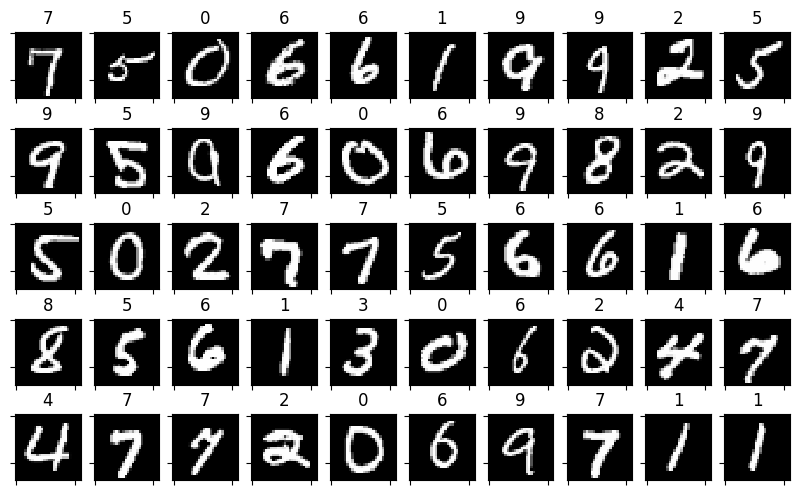

In [3]:
perm = np.random.permutation(list(range(X.shape[0])))[0:50]
random_imgs   = X[perm]
random_labels = y[perm]
fig = plt.figure(figsize=(10,6))
for i in range(random_imgs.shape[0]):
    ax=fig.add_subplot(5,10,i+1)
    plt.imshow(random_imgs[i].reshape(28,28), interpolation="nearest", cmap = plt.cm.Greys_r)
    ax.set_title(int(random_labels[i]))
    ax.set_xticklabels([])
    ax.set_yticklabels([])

and we do the regular train/test split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1200, 784), (300, 784), (1200,), (300,))

## 2. Building the data loading pipeline


setup a dataloader from the data arrays. **Observe we need to convert arrays to tensors**

In [5]:
tX_train = torch.from_numpy(X_train)
ty_train = torch.from_numpy(y_train)

tX_test = torch.from_numpy(X_test)
ty_test = torch.from_numpy(y_test)
tX_train, ty_train

(tensor([[0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.],
         [0., 0., 0.,  ..., 0., 0., 0.]]),
 tensor([0, 0, 7,  ..., 5, 0, 9]))

In [6]:
train_dataset = TensorDataset(tX_train, ty_train)
test_dataset = TensorDataset(tX_test, ty_test)

train_loader = DataLoader(
    train_dataset, 
    batch_size=32, 
    shuffle=True,      # Good practice for training
    num_workers=0      # Increase if on Linux/Mac for faster loading
)

we can now loop over the data

In [7]:
for x,y in train_loader:
    break

In [8]:
x.shape, y.shape

(torch.Size([32, 784]), torch.Size([32]))

## 3. Assemble and train an autoencoder

Observe how an autoencoder is just a concatenation of two regular `Linear` layers. **Why are we using a sigmoid as decoder output activation?**

In [9]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchinfo import summary
import lightning as L

class Autoencoder(L.LightningModule):
    def __init__(self, input_size, code_size):
        super().__init__()
        
        self.encoder = nn.Linear(input_size, code_size)
        self.decoder = nn.Linear(code_size, input_size)

        self.loss_history = []

    def forward(self, x):
        x = self.encoder(x)
        x = F.relu(x)
        x = self.decoder(x)
        x = F.sigmoid(x)
        return x

    def training_step(self, batch, batch_idx):
        x, _ = batch
        o = self.forward(x)
        self.loss = torch.mean((o-x)**2)
        self.log("train_loss", self.loss, on_step=False, on_epoch=True)
        return self.loss

    def configure_optimizers(self):
        optimizer = optim.Adam(self.parameters(), lr=0.005),
        return optimizer

    def on_train_epoch_end(self):
        self.loss_history.append(self.loss.detach().numpy())


# Example instantiation
model = Autoencoder(input_size=X_train.shape[1], code_size=50)
summary(model)

Layer (type:depth-idx)                   Param #
Autoencoder                              --
├─Linear: 1-1                            39,250
├─Linear: 1-2                            39,984
Total params: 79,234
Trainable params: 79,234
Non-trainable params: 0

test we can do inference on the model (still not trained)

In [10]:
o = model(x)
x.shape, o.shape

(torch.Size([32, 784]), torch.Size([32, 784]))

In [11]:
torch.mean((o-x)**2)

tensor(0.2327, grad_fn=<MeanBackward0>)

the training loop.

This is **self supervised** actual digit class `y` is not needed

In [12]:
trainer = L.Trainer(max_epochs=40) # Configure the trainer
trainer.fit(model=model, train_dataloaders=train_loader) 


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


┏━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder │ Linear │ 39.2 K │ train │     0 │
│ 1 │ decoder │ Linear │ 40.0 K │ train │     0 │
└───┴─────────┴────────┴────────┴───────┴───────┘

Trainable params: 79.2 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 79.2 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 2                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/opt/conda/envs/p312/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/conda/envs/p312/lib/python3.12/site-packages/lightning/pytorch/loops/fit_loop.py:317: The number of training batches (38) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to 

Text(0, 0.5, 'loss')

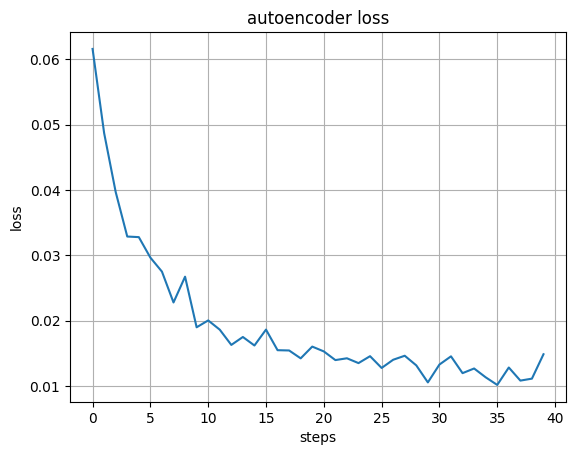

In [13]:
plt.plot(model.loss_history)
plt.grid()
plt.title('autoencoder loss')
plt.xlabel('steps')
plt.ylabel('loss')

The training seems to have gone well (the loss was reduced)

Question: How can we measure how good was the result?

You can try with larger layers, with more layers, etc.

## 4. Making predictions

We can feed the model any input and get the output. Observe we get eager tensors, which are like a symbolic wrapper to numpy matrices. We will see more about this later in this course.

In [14]:
o = model(tX_train)
o

tensor([[1.7924e-08, 1.3523e-06, 1.0222e-09,  ..., 6.9356e-10, 6.4846e-09,
         3.0347e-06],
        [1.0689e-06, 2.2963e-05, 3.8239e-07,  ..., 1.5216e-06, 2.8560e-06,
         5.5365e-05],
        [2.5405e-05, 2.7565e-04, 1.4685e-06,  ..., 1.4976e-06, 2.3287e-06,
         2.5468e-04],
        ...,
        [8.1770e-06, 3.5975e-06, 2.2275e-07,  ..., 8.2610e-06, 2.4179e-06,
         5.2102e-06],
        [2.2110e-09, 2.8854e-07, 3.3973e-11,  ..., 4.2320e-10, 2.9428e-10,
         9.1663e-07],
        [3.8301e-09, 4.5189e-07, 7.6120e-09,  ..., 6.2391e-08, 1.2187e-08,
         6.1541e-07]], grad_fn=<SigmoidBackward0>)

This is an autoencoder, so hopefuly the prediction (the reconstruction) should be similar to the input